1. Import Required Libraries

In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


2. Load the MNIST Dataset


In [ ]:
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


3. Preprocess the Images

In [ ]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5 # Normalize to [-1, 1]
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

4. Define Training Parameters

In [ ]:
batch_size = 64
noise_dim = 100
epochs = 30

5. Create Dataset Batches

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)

6. Build the Generator

In [ ]:
generator = keras.Sequential([
 keras.layers.Input(shape=(noise_dim,)),
 keras.layers.Dense(128, activation='relu'),
 keras.layers.Dense(28 * 28 * 1, activation='tanh'),
 keras.layers.Reshape((28, 28, 1))
])
print(generator.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

None


7. Build the Discriminator

In [ ]:
discriminator = keras.Sequential([
 keras.layers.Input(shape=(28, 28, 1)),
 keras.layers.Flatten(),
 keras.layers.Dense(128, activation='relu'),
 keras.layers.Dense(1, activation='sigmoid')
])
print(discriminator.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

None


8. Define Loss and Optimizers

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)

9. Training Process

In [ ]:
for epoch in range(epochs):
    for real_images in dataset:
        batch_size_now = real_images.shape[0]
        real_labels = tf.ones((batch_size_now, 1))
        fake_labels = tf.zeros((batch_size_now, 1))

        # Train Discriminator
        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:

            real_output = discriminator(real_images, training=True)
            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

        # Train Generator
        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:

            generated_images = generator(noise, training=True)
            output = discriminator(generated_images, training=True)

            g_loss = loss_fn(real_labels, output)

        g_gradients = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))


    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.numpy():.4f} G Loss: {g_loss.numpy():.4f}")

Epoch [1/30] D Loss: 0.3911 G Loss: 1.5549
Epoch [2/30] D Loss: 0.6142 G Loss: 1.3163
Epoch [3/30] D Loss: 1.2105 G Loss: 0.9374
Epoch [4/30] D Loss: 0.9629 G Loss: 1.1323
Epoch [5/30] D Loss: 0.7612 G Loss: 1.3794
Epoch [6/30] D Loss: 0.8783 G Loss: 1.2978
Epoch [7/30] D Loss: 0.4679 G Loss: 1.9698
Epoch [8/30] D Loss: 0.8285 G Loss: 1.6536
Epoch [9/30] D Loss: 0.9107 G Loss: 1.7060
Epoch [10/30] D Loss: 0.9209 G Loss: 1.6357
Epoch [11/30] D Loss: 0.7503 G Loss: 1.5455
Epoch [12/30] D Loss: 0.8647 G Loss: 1.6103
Epoch [13/30] D Loss: 0.6215 G Loss: 1.8379
Epoch [14/30] D Loss: 0.4360 G Loss: 2.2044
Epoch [15/30] D Loss: 0.5492 G Loss: 1.6919
Epoch [16/30] D Loss: 0.7135 G Loss: 1.6469
Epoch [17/30] D Loss: 0.9384 G Loss: 1.8621
Epoch [18/30] D Loss: 0.5311 G Loss: 1.9221
Epoch [19/30] D Loss: 1.0753 G Loss: 1.4924
Epoch [20/30] D Loss: 0.6012 G Loss: 2.2442
Epoch [21/30] D Loss: 1.4152 G Loss: 1.2519
Epoch [22/30] D Loss: 0.5661 G Loss: 2.0211
Epoch [23/30] D Loss: 0.7647 G Loss: 1.64

10.Generate images after training

In [ ]:
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise, training=False)

11. Display generated images

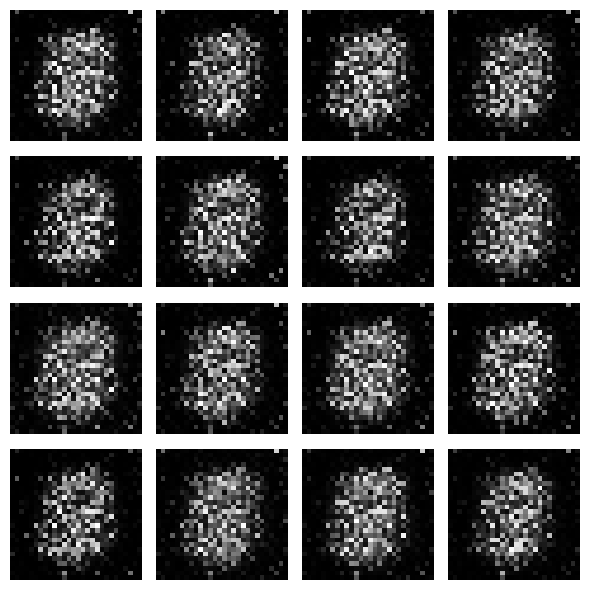

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
 ax.imshow((generated_images[i, :, :, 0] + 1) / 2, cmap='gray')
 ax.axis("off")
plt.tight_layout()
plt.show()